# PUBG Data Exploration and Random Forest with Funny GIFs

* [Preparation](#1)
* [Extra Data (Coming Soon)](#2)
* [Initial Exploration](#3)
* [Illegal Match](#4)
* [Feature Engineering](#5)
* [Outlier Detection](#6)
* [Categorical Variables](#7)
* [Preparation for Machine Learning](#8)
* [Feature Importance](#9)
* [Final Random Forest Model](#10)
* [Kaggle Submission](#11)


![Alt Text](https://media.giphy.com/media/xT9IgnOQS8e8uKkflK/giphy.gif)

In [1]:
from sklearn_pandas import DataFrameMapper

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [3]:
from pandas.api.types import is_string_dtype, is_numeric_dtype

In [4]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [5]:
# from sklearn_pandas import DataFrameMapper
# from sklearn.preprocessing import LabelEncoder, Imputer, StandardScaler
# from pandas.api.types import is_string_dtype, is_numeric_dtype
# from sklearn.ensemble import forest
from sklearn.tree import export_graphviz

def get_sample(df,n):
    """ Gets a random sample of n rows from df, without replacement.
    Parameters:
    -----------
    df: A pandas data frame, that you wish to sample from.
    n: The number of rows you wish to sample.
    Returns:
    --------
    return value: A random sample of n rows of df.
    Examples:
    ---------
    >>> df = pd.DataFrame({'col1' : [1, 2, 3], 'col2' : ['a', 'b', 'a']})
    >>> df
       col1 col2
    0     1    a
    1     2    b
    2     3    a
    >>> get_sample(df, 2)
       col1 col2
    2     3    a
    1     2    b
    """
    idxs = sorted(np.random.permutation(len(df))[:n])
    return df.iloc[idxs].copy()

def proc_df(df, y_fld, skip_flds=None, do_scale=False, na_dict=None,
            preproc_fn=None, max_n_cat=None, subset=None, mapper=None):

    """ proc_df takes a data frame df and splits off the response variable, and
    changes the df into an entirely numeric dataframe.
    Parameters:
    -----------
    df: The data frame you wish to process.
    y_fld: The name of the response variable
    skip_flds: A list of fields that dropped from df.
    do_scale: Standardizes each column in df,Takes Boolean Values(True,False)
    na_dict: a dictionary of na columns to add. Na columns are also added if there
        are any missing values.
    preproc_fn: A function that gets applied to df.
    max_n_cat: The maximum number of categories to break into dummy values, instead
        of integer codes.
    subset: Takes a random subset of size subset from df.
    mapper: If do_scale is set as True, the mapper variable
        calculates the values used for scaling of variables during training time(mean and standard deviation).
    Returns:
    --------
    [x, y, nas, mapper(optional)]:
        x: x is the transformed version of df. x will not have the response variable
            and is entirely numeric.
        y: y is the response variable
        nas: returns a dictionary of which nas it created, and the associated median.
        mapper: A DataFrameMapper which stores the mean and standard deviation of the corresponding continous
        variables which is then used for scaling of during test-time.
    Examples:
    ---------
    >>> df = pd.DataFrame({'col1' : [1, 2, 3], 'col2' : ['a', 'b', 'a']})
    >>> df
       col1 col2
    0     1    a
    1     2    b
    2     3    a
    note the type of col2 is string
    >>> train_cats(df)
    >>> df
       col1 col2
    0     1    a
    1     2    b
    2     3    a
    now the type of col2 is category { a : 1, b : 2}
    >>> x, y, nas = proc_df(df, 'col1')
    >>> x
       col2
    0     1
    1     2
    2     1
    >>> data = DataFrame(pet=["cat", "dog", "dog", "fish", "cat", "dog", "cat", "fish"],
                 children=[4., 6, 3, 3, 2, 3, 5, 4],
                 salary=[90, 24, 44, 27, 32, 59, 36, 27])
    >>> mapper = DataFrameMapper([(:pet, LabelBinarizer()),
                          ([:children], StandardScaler())])
    >>>round(fit_transform!(mapper, copy(data)), 2)
    8x4 Array{Float64,2}:
    1.0  0.0  0.0   0.21
    0.0  1.0  0.0   1.88
    0.0  1.0  0.0  -0.63
    0.0  0.0  1.0  -0.63
    1.0  0.0  0.0  -1.46
    0.0  1.0  0.0  -0.63
    1.0  0.0  0.0   1.04
    0.0  0.0  1.0   0.21
    """
    if not skip_flds: skip_flds=[]
    if subset: df = get_sample(df,subset)
    df = df.copy()
    if preproc_fn: preproc_fn(df)
    y = df[y_fld].values
    df.drop(skip_flds+[y_fld], axis=1, inplace=True)

    if na_dict is None: na_dict = {}
    for n,c in df.items(): na_dict = fix_missing(df, c, n, na_dict)
    if do_scale: mapper = scale_vars(df, mapper)
    for n,c in df.items(): numericalize(df, c, n, max_n_cat)
    res = [pd.get_dummies(df, dummy_na=True), y, na_dict]
    if do_scale: res = res + [mapper]
    return res

def rf_feat_importance(m, df):
    return pd.DataFrame({'cols':df.columns, 'imp':m.feature_importances_}
                       ).sort_values('imp', ascending=False)

def set_rf_samples(n):
    """ Changes Scikit learn's random forests to give each tree a random sample of
    n random rows.
    """
    forest._generate_sample_indices = (lambda rs, n_samples:
        forest.check_random_state(rs).randint(0, n_samples, n))

def reset_rf_samples():
    """ Undoes the changes produced by set_rf_samples.
    """
    forest._generate_sample_indices = (lambda rs, n_samples:
        forest.check_random_state(rs).randint(0, n_samples, n_samples))

In [6]:
# For autoreloading modules
# %load_ext autoreload
# %autoreload 2
# For notebook plotting
%matplotlib inline

# Standard libraries
import os
import numpy as np
import pandas as pd

In [7]:
# !pip install pdpbox plotnine pandas_summary

In [8]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pdpbox import pdp
from plotnine import *
from pandas_summary import DataFrameSummary
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display

In [9]:
# Machine Learning
import sklearn
from sklearn import metrics
from scipy.cluster import hierarchy as hc
from fastai.imports import *

In [10]:
# # Directories
# KAGGLE_DIR = '../input/'

# # Info about dataset
# print('Files and directories: \n{}\n'.format(os.listdir("../input")))

# print('\n# File sizes')
# for file in os.listdir(KAGGLE_DIR):
#     print('{}| {} MB'.format(file.ljust(30),
#                              str(round(os.path.getsize(KAGGLE_DIR + file) / 1000000, 2))))

In [11]:
# Import dataset
train = pd.read_csv('train_V2_sample.csv')
test = pd.read_csv('test_V2_sample.csv')

# Initial Exploration <a id="3"></a>

In [12]:
# First five rows (From Head)
print('First 5 rows: ')
display(train.head())

# Last five rows (To Tail)
print('Last 5 rows: ')
display(train.tail())

First 5 rows: 


,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


Last 5 rows: 


,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
20645,b3e32420ec792c,45961a6cd84526,ad66849af0e045,0,0,100.0,1,0,0,33,...,0,0.0,0,0.00,0,0,53.31,3,1567,0.3846
20646,e14d2829691ceb,def7bd6e078e05,b0c7739ff40ab9,0,0,118.7,0,0,0,31,...,0,0.0,0,0.00,0,0,732.60,7,1477,0.4043
20647,c80ca00363425a,d76d36a4c73536,d89a6d44a9bb1b,0,0,0.0,0,0,0,58,...,1,0.0,0,0.00,0,0,744.70,4,0,0.4783
20648,f5b1ed7d3b96e1,f3e0792764d7c7,054d4e5993cf8b,0,0,0.0,0,0,0,96,...,0,0.0,0,0.00,0,0,62.35,1,0,0.0000
20649,0030f752f98f50,a6fac74657b491,24c7c6f451fd5f,0,0,0.0,0,0,0,57,...,0,0.0,0,6.59,0,0,1056.00,5,0,0.4894


Summary Statistics of the training data.

In [13]:
# Stats
train.describe()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,...,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000,20650.000000
mean,0.238111,1.132397,131.183393,0.665085,0.225182,1.389395,47.414383,508.396077,0.929346,0.548475,...,0.164165,608.871078,0.003341,4.595480,0.024504,0.008087,1160.320298,3.689879,610.260872,0.474804
std,0.586472,1.738985,170.752296,1.168246,0.576507,2.701190,27.495482,628.330187,1.544063,0.718368,...,0.469181,1491.977220,0.073900,31.126511,0.172101,0.092230,1177.015770,2.396969,740.139803,0.307545
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,160.400000,2.000000,0.000000,0.200000
50%,0.000000,0.000000,82.515000,0.000000,0.000000,0.000000,47.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,710.400000,3.000000,0.000000,0.463650
75%,0.000000,2.000000,186.375000,1.000000,0.000000,2.000000,71.000000,1175.000000,1.000000,1.000000,...,0.000000,9.233250,0.000000,0.000000,0.000000,0.000000,1966.750000,5.000000,1495.000000,0.740700
max,9.000000,14.000000,2856.000000,32.000000,8.000000,47.000000,100.000000,2069.000000,24.000000,7.000000,...,8.000000,17210.000000,4.000000,1171.000000,4.000000,2.000000,9325.000000,43.000000,1906.000000,1.000000


Data types, memory usage, shape, etc.

In [14]:
# Types, Data points, memory usage, etc.
train.info()

# Check dataframe's shape
print('Shape of training set: ', train.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20650 entries, 0 to 20649
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               20650 non-null  object 
 1   groupId          20650 non-null  object 
 2   matchId          20650 non-null  object 
 3   assists          20650 non-null  int64  
 4   boosts           20650 non-null  int64  
 5   damageDealt      20650 non-null  float64
 6   DBNOs            20650 non-null  int64  
 7   headshotKills    20650 non-null  int64  
 8   heals            20650 non-null  int64  
 9   killPlace        20650 non-null  int64  
 10  killPoints       20650 non-null  int64  
 11  kills            20650 non-null  int64  
 12  killStreaks      20650 non-null  int64  
 13  longestKill      20650 non-null  float64
 14  matchDuration    20650 non-null  int64  
 15  matchType        20650 non-null  object 
 16  maxPlace         20650 non-null  int64  
 17  numGroups   

### Feature descriptions (From Kaggle)

* DBNOs - Number of enemy players knocked.
* assists - Number of enemy players this player damaged that were killed by teammates.
* boosts - Number of boost items used.
* damageDealt - Total damage dealt. Note: Self inflicted damage is subtracted.
* headshotKills - Number of enemy players killed with headshots.
* heals - Number of healing items used.
* Id - Player’s Id
* killPlace - Ranking in match of number of enemy players killed.
* killPoints - Kills-based external ranking of player. (Think of this as an Elo ranking where only kills matter.) If there is a value other than -1 in rankPoints, then any 0 in killPoints should be treated as a “None”.
* killStreaks - Max number of enemy players killed in a short amount of time.
* kills - Number of enemy players killed.
* longestKill - Longest distance between player and player killed at time of death. This may be misleading, as downing a player and driving away may lead to a large longestKill stat.
* matchDuration - Duration of match in seconds.
* matchId - ID to identify match. There are no matches that are in both the training and testing set.
* matchType - String identifying the game mode that the data comes from. The standard modes are “solo”, “duo”, “squad”, “solo-fpp”, “duo-fpp”, and “squad-fpp”; other modes are from events or custom matches.
* rankPoints - Elo-like ranking of player. This ranking is inconsistent and is being deprecated in the API’s next version, so use with caution. Value of -1 takes place of “None”.
* revives - Number of times this player revived teammates.
* rideDistance - Total distance traveled in vehicles measured in meters.
* roadKills - Number of kills while in a vehicle.
* swimDistance - Total distance traveled by swimming measured in meters.
* teamKills - Number of times this player killed a teammate.
* vehicleDestroys - Number of vehicles destroyed.
* walkDistance - Total distance traveled on foot measured in meters.
* weaponsAcquired - Number of weapons picked up.
* winPoints - Win-based external ranking of player. (Think of this as an Elo ranking where only winning matters.) If there is a value other than -1 in rankPoints, then any 0 in winPoints should be treated as a “None”.
* groupId - ID to identify a group within a match. If the same group of players plays in different matches, they will have a different groupId each time.
* numGroups - Number of groups we have data for in the match.
* maxPlace - Worst placement we have data for in the match. This may not match with numGroups, as sometimes the data skips over placements.
* winPlacePerc - The target of prediction. This is a percentile winning placement, where 1 corresponds to 1st place, and 0 corresponds to last place in the match. It is calculated off of maxPlace, not numGroups, so it is possible to have missing chunks in a match.

[Source](https://www.kaggle.com/c/pubg-finish-placement-prediction/data)

In [15]:
# Use this code if you want to store and read DataFrames in a feather format
# os.makedirs('tmp', exist_ok=True)
# train.to_feather('tmp/PUBG')
# df_raw = pd.read_feather('tmp/PUBG')

# Illegal Match <a id="4"></a>

Fellow Kaggler '[averagemn](https://www.kaggle.com/donkeys)' brought to our attention that there is one particular player with a 'winPlacePerc' of NaN. The case was that this match had only one player. We will delete this row from our dataset.

In [16]:
# Check row with NaN value
train[train['winPlacePerc'].isnull()]

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc


Let's delete this entry:

In [17]:
# Drop row with NaN 'winPlacePerc' value
# train.drop(2744604, inplace=True)

And he's gone!

In [18]:
# The row at index 2744604 will be gone
train[train['winPlacePerc'].isnull()]

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc


# Feature Engineering <a id="5"></a>

Earlier in this kernel we created the new features ''totalDistance'' and  ''headshot_rate". In this section we add more interesting features to improve the predictive quality of our machine learning models.

Initial ideas for this section come from [this amazing kernel](https://www.kaggle.com/deffro/eda-is-fun).

Note: It is important with feature engineering that you also add the engineered features to your test set!

### Players Joined

This is likely a very valuable feature for our model. If we know how many people are in a match we can normalize other features and get stronger predictions on individual players.

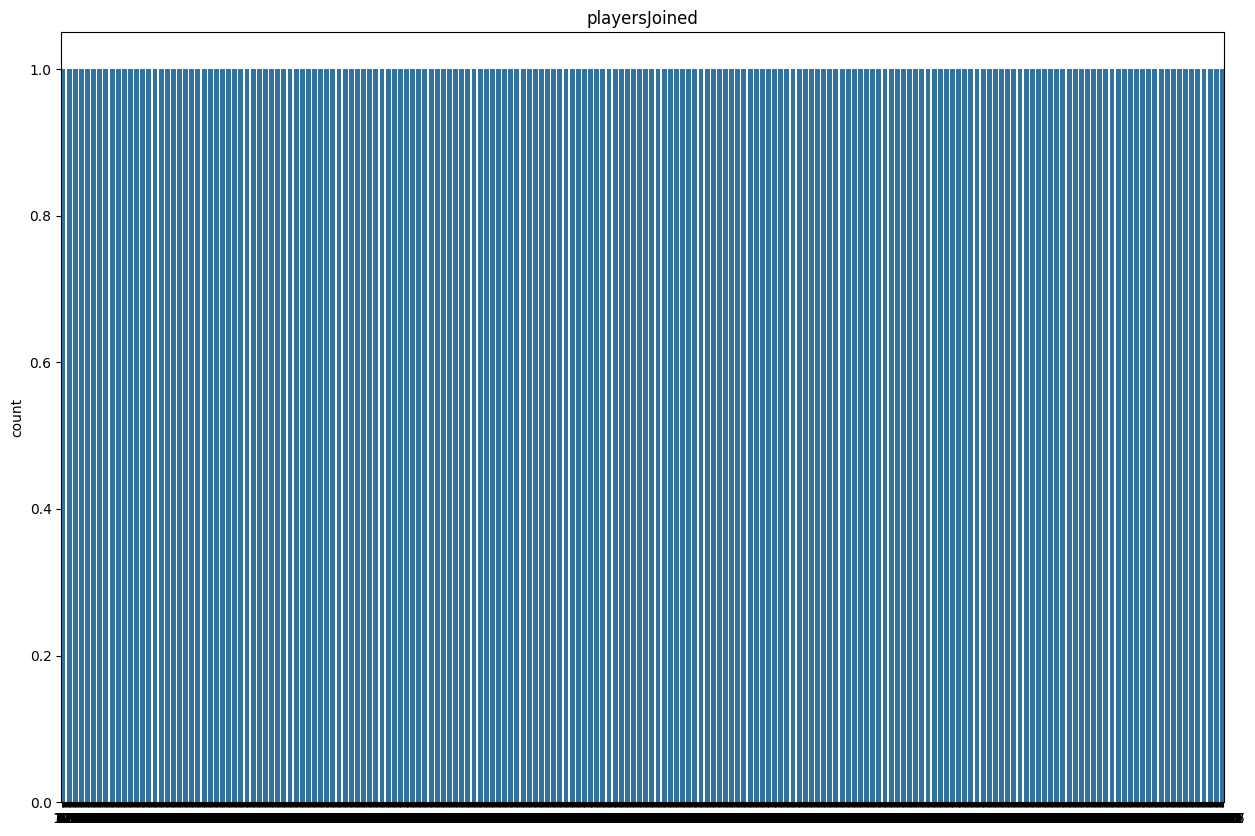

In [19]:
# playersJoined
train['playersJoined'] = train.groupby('matchId')['matchId'].transform('count')
plt.figure(figsize=(15,10))
sns.countplot(train[train['playersJoined']>=3]['playersJoined'])
plt.title('playersJoined')
plt.show()

### Normalized features

Now that we have a feature 'playersJoined' we can normalize other features based on the amount of players. Features that can be valuable to normalize are:
1. kills
2. damageDealt
3. maxPlace
4. matchDuration

Let's try out some things!

**Normalize features**

In [20]:
# Create normalized features
train['killsNorm'] = train['kills']*((100-train['playersJoined'])/100 + 1)
train['damageDealtNorm'] = train['damageDealt']*((100-train['playersJoined'])/100 + 1)
train['maxPlaceNorm'] = train['maxPlace']*((100-train['playersJoined'])/100 + 1)
train['matchDurationNorm'] = train['matchDuration']*((100-train['playersJoined'])/100 + 1)
# Compare standard features and normalized features
to_show = ['Id', 'kills','killsNorm','damageDealt', 'damageDealtNorm', 'maxPlace', 'maxPlaceNorm', 'matchDuration', 'matchDurationNorm']
train[to_show][0:11]

,Id,kills,killsNorm,damageDealt,damageDealtNorm,maxPlace,maxPlaceNorm,matchDuration,matchDurationNorm
0,7f96b2f878858a,0,0.00,0.000,0.00000,28,55.44,1306,2585.88
1,eef90569b9d03c,0,0.00,91.470,181.11060,26,51.48,1777,3518.46
2,1eaf90ac73de72,0,0.00,68.000,135.32000,50,99.50,1318,2622.82
3,4616d365dd2853,0,0.00,32.900,64.48400,31,60.76,1436,2814.56
4,315c96c26c9aac,1,1.99,100.000,199.00000,97,193.03,1424,2833.76
5,ff79c12f326506,1,1.99,100.000,199.00000,28,55.72,1395,2776.05
6,95959be0e21ca3,0,0.00,0.000,0.00000,28,54.88,1316,2579.36
7,311b84c6ff4390,0,0.00,8.538,16.99062,96,191.04,1967,3914.33
8,1a68204ccf9891,0,0.00,51.600,102.68400,28,55.72,1375,2736.25
9,e5bb5a43587253,0,0.00,37.270,74.16730,29,57.71,1930,3840.70


### Heals and Boosts

We create a feature called 'healsandboosts' by adding heals and boosts. (duh!) We are not sure if this has additional predictive value, but we can always delete it later if the feature importance according to our random forest model is too low.

In [21]:
# Create new feature healsandboosts
train['healsandboosts'] = train['heals'] + train['boosts']
train[['heals', 'boosts', 'healsandboosts']].tail()

,heals,boosts,healsandboosts
20645,0,0,0
20646,0,0,0
20647,0,0,0
20648,0,0,0
20649,0,0,0


### Killing without moving

We try to identify cheaters by checking if people are getting kills without moving. We first identify the totalDistance travelled by a player and then set a boolean value to True if someone got kills without moving a single inch. We will remove cheaters in our outlier detection section.

In [22]:
# Create feature totalDistance
train['totalDistance'] = train['rideDistance'] + train['walkDistance'] + train['swimDistance']
# Create feature killsWithoutMoving
train['killsWithoutMoving'] = ((train['kills'] > 0) & (train['totalDistance'] == 0))

The feature headshot_rate will also help us to catch cheaters.

In [23]:
# Create headshot_rate feature
train['headshot_rate'] = train['headshotKills'] / train['kills']
train['headshot_rate'] = train['headshot_rate'].fillna(0)

# Outlier Detection <a id="6"></a>

Some rows in our dataset have weird characteristics. The players could be cheaters, maniacs or just anomalies. Removing these outliers will likely improve results.

Inspiration for this section comes from [this amazing Kaggle Kernel.](https://www.kaggle.com/rejasupotaro/cheaters-and-zombies)

![Alt Text](https://media.giphy.com/media/OPRbXcsGctvZC/giphy.gif)

**Kills without movement**

This is perhaps the most obvious sign of cheating in the game. It is already fishy if a player hasn't moved during the whole game, but the player could be AFK and got killed. However, if the player managed to get kills without moving it is most likely a cheater.

In [24]:
# Check players who kills without moving
display(train[train['killsWithoutMoving'] == True].shape)
train[train['killsWithoutMoving'] == True].head(10)

(5, 38)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
1824,b538d514ef2476,0eb2ce2f43f9d6,35e7d750e442e2,0,0,593.0,0,0,3,18,...,0.8571,1,11.94,1180.070,29.85,1180.07,3,0.0,True,0.0
6673,6d3a61da07b7cb,2d8119b1544f87,904cecf36217df,2,0,346.6,0,0,6,33,...,0.6000,2,5.94,686.268,21.78,3552.12,6,0.0,True,0.0
11892,550398a8f33db7,c3fd0e2abab0af,db6f6d1f0d4904,2,0,1750.0,0,4,5,3,...,0.8947,1,39.80,3482.500,39.80,1787.02,5,0.0,True,0.2
14631,58d690ee461e9d,ea5b6630b33d67,dbf34301df5e53,0,0,157.8,0,0,0,69,...,0.0000,1,1.99,314.022,37.81,1590.01,0,0.0,True,0.0
15591,49b61fc963d632,0f5c5f19d9cc21,904cecf36217df,0,0,100.0,0,1,0,37,...,0.3000,2,1.98,198.000,21.78,3552.12,0,0.0,True,1.0


Got the suckers!

In [25]:
# Remove outliers
train.drop(train[train['killsWithoutMoving'] == True].index, inplace=True)

**Anomalies in roadKills**

In [26]:
# Players who got more than 1 roadKills
train[train['roadKills'] > 1]

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
5844,1b3e3ec450d699,b6b8293b52b6c4,5569c534a8169c,1,5,468.0,3,0,4,7,...,0.7143,1,7.96,931.320,99.50,3759.11,9,5090.000,False,0.0
8017,45f401a176260d,2e614bb5b0a353,be945f2803814a,0,0,224.3,1,0,1,7,...,0.9592,2,5.94,444.114,99.00,1811.70,1,6358.820,False,0.0
14430,7bcd3aa231031a,da5cf59592471e,c482a293b96b41,0,3,146.8,0,0,10,3,...,0.9444,1,5.97,292.132,37.81,1761.15,13,5115.900,False,0.0
14609,cbca946554c4ab,c5a9de82ce9b0d,f03bba9414fa91,1,1,301.4,2,0,1,9,...,0.7143,2,5.94,596.772,57.42,3704.58,2,9407.500,False,0.0
14867,8c6a588f966542,b7768ddf56d1c6,4952d22e4a7b38,1,0,251.2,2,0,0,20,...,0.0741,1,3.98,499.888,55.72,3824.78,0,1004.777,False,0.0
15347,10dad8a885f847,36125fc1da9447,098b32c9c9ceb3,3,4,1085.0,4,0,2,1,...,0.8571,2,21.78,2148.300,71.28,1791.90,6,8150.000,False,0.0
18794,70fca2e408a6a1,5871af7d3e10d8,e49c1077582711,0,4,416.8,0,0,4,5,...,0.8617,3,7.88,821.096,187.15,3581.46,8,7187.000,False,0.0
19790,0887db70259b5e,50418b437e0790,f32b7736e8fe24,1,0,377.8,3,0,0,5,...,0.6531,1,7.96,751.822,99.50,1767.12,0,5676.000,False,0.0


In [27]:
# Drop roadKill 'cheaters'
train.drop(train[train['roadKills'] > 10].index, inplace=True)

Note that player c3e444f7d1289d drove 5 meters but killed 14 people with it. Sounds insane doesn't it?

![Alt Text](https://media.giphy.com/media/3o7aD85usFbbbrCR3i/giphy.gif)

**Anomalies in aim (More than 45 kills)**

Let's plot the total kills for every player first. It doesn't look like there are too many outliers.

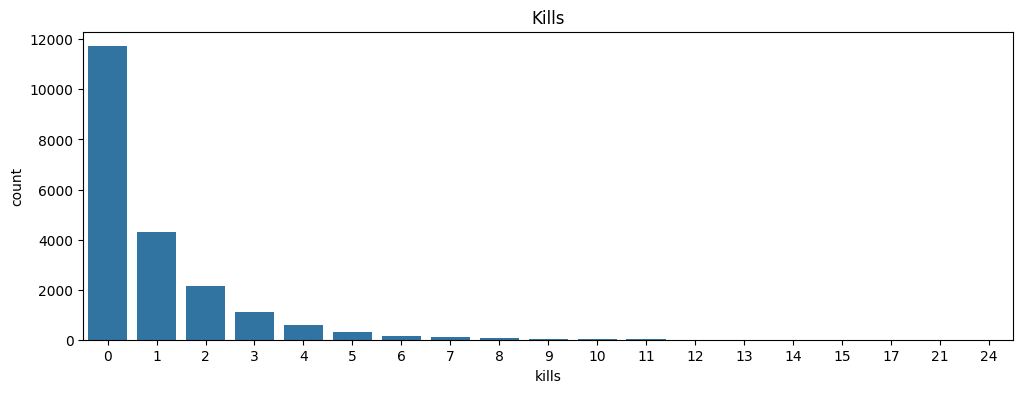

In [28]:
# Plot the distribution of kills
plt.figure(figsize=(12,4))
sns.countplot(data=train, x=train['kills']).set_title('Kills')
plt.show()

Let's take a closer look.

In [29]:
# Players who got more than 30 kills
display(train[train['kills'] > 15].shape)
train[train['kills'] > 15].head(10)

(4, 38)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
2569,7711e1d39407da,a9fbc63469296f,45fc89f9b11eaf,1,4,2325.0,13,8,2,1,...,1.0000,1,41.79,4626.75,97.51,2738.24,6,4709.0,False,0.380952
5589,0fa60dc56fdb16,bba49001a7a90b,1ddf8645b8648a,1,11,2033.0,13,4,7,1,...,1.0000,2,33.66,4025.34,99.00,3674.88,18,4451.0,False,0.235294
18038,40653224d253d8,42cae07423e22a,8a728def0644be,6,0,1806.0,19,5,12,16,...,0.4615,1,33.83,3593.94,27.86,2384.02,12,435.1,False,0.294118
19531,ef706f0f248dbf,f27e63bfc6746c,7d2fd7f5d4f8b2,9,0,2856.0,32,3,0,1,...,0.8000,1,47.76,5683.44,11.94,2378.05,0,1136.0,False,0.125000


In [30]:
# Remove outliers
train.drop(train[train['kills'] > 30].index, inplace=True)

What do you think? Should we remove all these outliers from our dataset?

**Anomalies in aim part 2 (100% headshot rate)**

Again, we first take a look at the whole dataset and create a new feature 'headshot_rate'.
We see that the most players score in the 0 to 10% region. However, there are a few anomalies that have a headshot_rate of 100% percent with more than 9 kills!

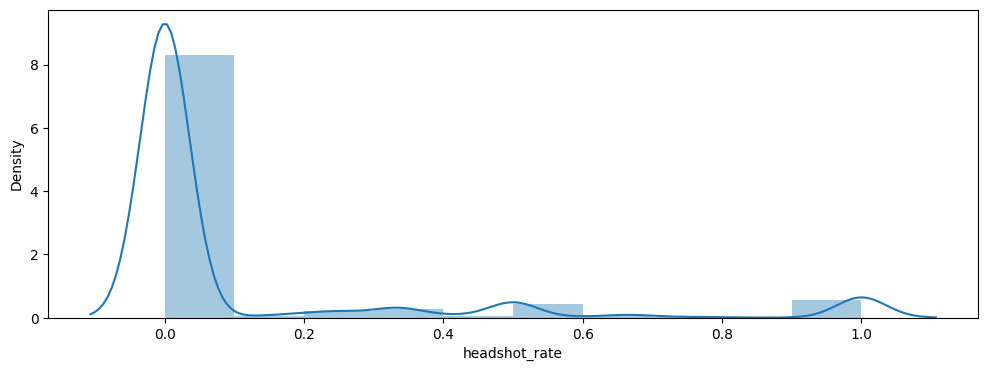

In [31]:
# Plot the distribution of headshot_rate
plt.figure(figsize=(12,4))
sns.distplot(train['headshot_rate'], bins=10)
plt.show()

In [32]:
# Players who made a minimum of 10 kills and have a headshot_rate of 100%
display(train[(train['headshot_rate'] == 1) & (train['kills'] > 2)].shape)
train[(train['headshot_rate'] == 1) & (train['kills'] > 2)].head(10)

(20, 38)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
2897,7352cab7cf13c3,efb8a6069862c0,2d06c3a9b6fbac,0,10,476.4,0,4,14,2,...,0.9892,1,7.96,948.036,187.06,4234.72,24,14238.00,False,1.0
3517,12b7d76587ce37,30981199402a18,c2212a5338abb4,0,0,241.1,1,3,1,9,...,0.8085,2,5.94,477.378,95.04,3894.66,1,2702.00,False,1.0
3646,e19f3c39711470,74206f01bab49b,a2ffc69eeae9a0,0,4,443.5,2,5,2,3,...,0.9556,1,9.95,882.565,91.54,2752.17,6,3065.00,False,1.0
3688,e7ef7b94cd8873,823b29b9a2df03,f09e921dde3f57,0,1,436.1,0,3,1,9,...,0.6957,1,5.97,867.839,93.53,2742.22,2,1547.39,False,1.0
4426,1378118490d715,fec0b765247a53,b1d39a44637162,2,2,583.1,3,3,2,8,...,0.9535,1,5.97,1160.369,87.56,3564.09,4,11373.00,False,1.0
4482,50f37d0ba6e102,73408c9c50294a,3774589f6db825,0,4,427.9,2,4,4,8,...,0.8519,1,7.96,851.521,55.72,3669.56,8,6530.00,False,1.0
6294,9ee3b52220e0ee,c2e61da9e1560d,bc7d17490128b2,1,3,506.4,2,3,0,10,...,0.7083,1,5.97,1007.736,97.51,3649.66,3,5170.00,False,1.0
6483,4545c95e498f96,b1902c9817b107,2.06006E+13,0,3,596.2,4,5,2,5,...,0.9286,1,9.95,1186.438,57.71,2885.50,5,2638.00,False,1.0
7171,6dea9e64e02161,70664f89e25949,e3530e2b31bfdb,1,7,245.2,2,3,6,4,...,0.9630,2,5.94,485.496,55.44,2694.78,13,4285.00,False,1.0
9231,b84727a4191bfa,41a311167b29d9,a80ca287e2a49c,0,1,371.2,2,3,0,10,...,0.6667,1,5.97,738.688,97.51,2672.57,1,1887.90,False,1.0


It is unclear if these players are cheating so we are probably not deleting these players from the dataset.
If they are legitimate players, they are probably really crushing the game!

![Alt Text](https://media.giphy.com/media/l3mZrOajz5VCZf7Hy/giphy.gif)


**Anomalies in aim part 3 (Longest kill)**

Most kills are made from a distance of 100 meters or closer. There are however some outliers who make a kill from more than 1km away. This is probably done by cheaters.

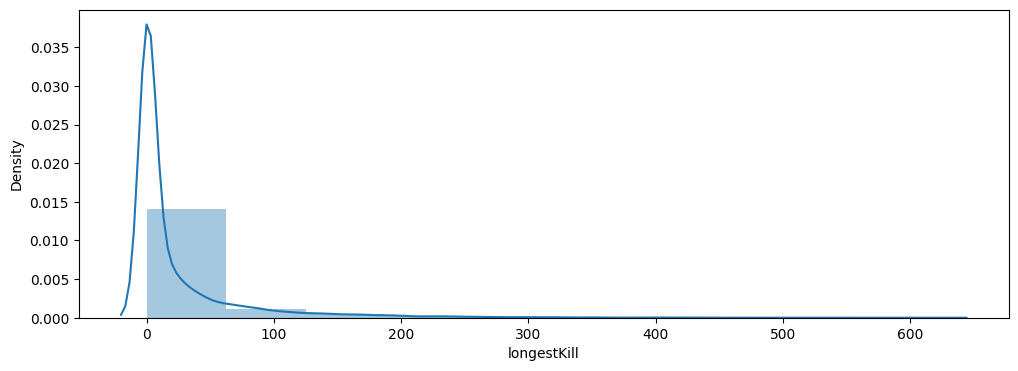

In [33]:
# Plot the distribution of longestKill
plt.figure(figsize=(12,4))
sns.distplot(train['longestKill'], bins=10)
plt.show()

Let's take a look at the players who make these shots.

In [34]:
# Check out players who made kills with a distance of more than 1 km
display(train[train['longestKill'] >= 500].shape)
train[train['longestKill'] >= 500].head(10)

(1, 38)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
4538,03313d3ed6011d,889425599a132c,c14a056614e5bb,1,8,745.5,5,0,3,2,...,1.0,2,11.88,1476.09,61.38,3730.32,11,4861.5,False,0.0


In [35]:
# Remove outliers
train.drop(train[train['longestKill'] >= 1000].index, inplace=True)

There is something fishy going on with these players. We are probably better off removing them from our dataset.

![Alt Text](https://media.giphy.com/media/RHJkLqcdvMQF4GI3P7/giphy.gif)

**Anomalies in travelling (rideDistance, walkDistance and swimDistance)**

Let's check out anomalies in Distance travelled.

In [36]:
# Summary statistics for the Distance features
train[['walkDistance', 'rideDistance', 'swimDistance', 'totalDistance']].describe()

,walkDistance,rideDistance,swimDistance,totalDistance
count,20645.000000,20645.000000,20645.000000,20645.000000
mean,1160.601315,609.018540,4.596593,1774.216449
std,1177.019751,1492.127794,31.130198,2174.129496
min,0.000000,0.000000,0.000000,0.000000
25%,160.600000,0.000000,0.000000,163.400000
50%,710.900000,0.000000,0.000000,815.900000
75%,1967.000000,9.289000,0.000000,2735.200000
max,9325.000000,17210.000000,1171.000000,17834.100000


**walkDistance**

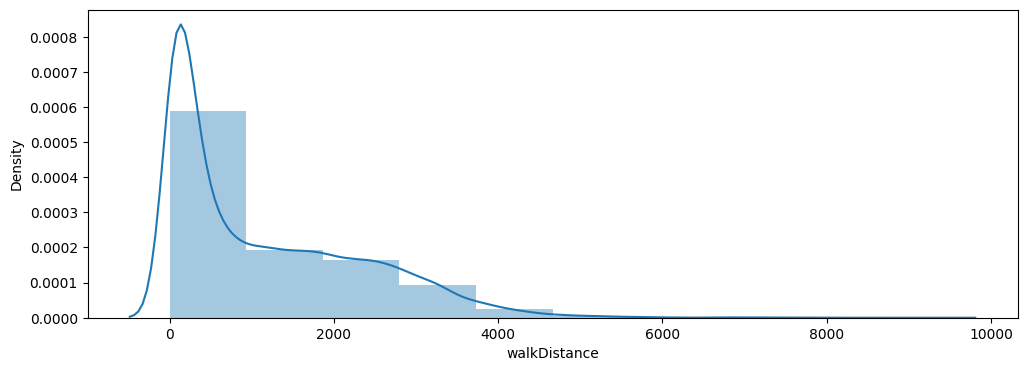

In [37]:
# Plot the distribution of walkDistance
plt.figure(figsize=(12,4))
sns.distplot(train['walkDistance'], bins=10)
plt.show()

In [38]:
# walkDistance anomalies
display(train[train['walkDistance'] >= 2000].shape)
train[train['walkDistance'] >= 2000].head(10)

(5051, 38)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
12,ce4f6ac165705e,da24cdb91969cc,535b5dbd965a94,0,0,0.00,0,0,0,37,...,0.9286,1,0.00,0.0000,57.71,3530.26,0,9423.00,False,0.000000
13,b7807186e3f679,3c08e461874749,2c30ddf481c52d,0,1,324.20,0,1,5,5,...,0.8750,2,7.92,641.9160,192.06,3734.28,6,3354.84,False,0.250000
16,62f2f0917d84b2,f61b698274d9f5,1d6cfe0f6f23b0,0,2,81.71,1,0,14,25,...,0.7308,1,1.99,162.6029,53.73,3745.18,16,4193.90,False,0.000000
19,71cbdbc3b263e5,7b61f74b51906c,a329ac99449ad7,0,1,65.28,0,0,1,48,...,0.9310,1,0.00,129.9072,59.70,2630.78,2,3330.85,False,0.000000
23,0b6fbdfb59c994,7a75c3e86934f6,8b0a78c005cea0,0,6,1011.00,6,2,2,2,...,0.9592,1,17.91,2011.8900,99.50,3695.43,8,7587.00,False,0.222222
24,736eda9b9c20b3,d35e80e4e64dd4,62fbe726028662,0,3,327.60,4,1,1,3,...,0.9231,1,7.96,651.9240,53.73,2893.46,4,3503.00,False,0.250000
25,4c45dc732689ec,8e0a0ea95d3596,37f43ba55ec0a4,1,4,558.60,3,0,4,11,...,0.8696,1,5.97,1111.6140,93.53,3663.59,8,3894.00,False,0.000000
28,f9473c4f1cfdc4,8483976f3ba230,6057f846f3ed12,0,6,345.60,2,1,1,6,...,0.9630,1,7.96,687.7440,55.72,2664.61,7,3855.00,False,0.250000
38,5cb863f7ac0dcd,667d7cda387b5c,2d3bb641903718,1,0,318.00,2,0,0,5,...,0.7021,1,7.96,632.8200,95.52,2716.35,0,2303.00,False,0.000000
44,46ec2eef21c254,0fe2d5264ebb8e,a1a7ef866a79be,0,4,401.20,3,0,6,27,...,0.7872,2,1.98,794.3760,95.04,3771.90,10,2576.00,False,0.000000


In [39]:
# Remove outliers
train.drop(train[train['walkDistance'] >= 10000].index, inplace=True)

**rideDistance**

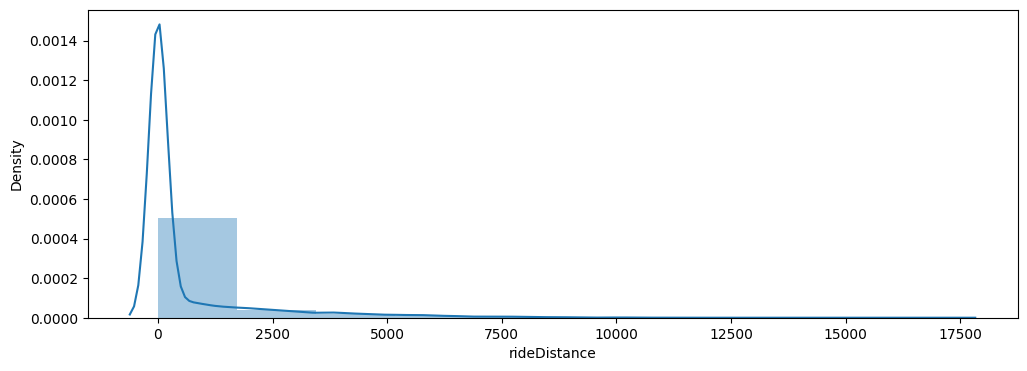

In [40]:
# Plot the distribution of rideDistance
plt.figure(figsize=(12,4))
sns.distplot(train['rideDistance'], bins=10)
plt.show()

In [41]:
# rideDistance anomalies
display(train[train['rideDistance'] >= 2000].shape)
train[train['rideDistance'] >= 2000].head(10)

(2410, 38)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
7,311b84c6ff4390,eaba5fcb7fc1ae,292611730ca862,0,0,8.538,0,0,0,48,...,0.7368,1,0.00,16.99062,191.04,3914.33,0,3093.000,False,0.000000
12,ce4f6ac165705e,da24cdb91969cc,535b5dbd965a94,0,0,0.000,0,0,0,37,...,0.9286,1,0.00,0.00000,57.71,3530.26,0,9423.000,False,0.000000
17,92022479b92ce7,2f2c33f548c4b9,07948d723b9c0f,0,3,254.300,0,0,12,13,...,0.8211,1,3.98,506.05700,191.04,2728.29,15,4169.290,False,0.000000
20,02ace8c6e58461,a4bc548028f800,80f2b8448e474b,0,4,269.100,0,1,8,18,...,0.6383,1,3.98,535.50900,95.52,3761.10,12,4528.000,False,0.500000
22,9b2961d4d51f91,799d0a4d61dc3c,e833ca2282169d,0,1,192.300,1,2,3,15,...,0.7500,1,3.98,382.67700,97.51,3532.25,4,3596.000,False,1.000000
23,0b6fbdfb59c994,7a75c3e86934f6,8b0a78c005cea0,0,6,1011.000,6,2,2,2,...,0.9592,1,17.91,2011.89000,99.50,3695.43,8,7587.000,False,0.222222
75,03cab96432e075,d9cb24f1a28ccb,1845c9080c7186,0,3,164.800,0,0,9,54,...,0.6522,2,0.00,326.30400,93.06,3696.66,12,6768.096,False,0.000000
107,7970b4ea89e81e,abf9e2780b9f48,04832cfd74ff30,1,1,58.360,0,0,2,38,...,1.0000,3,0.00,114.96920,51.22,3364.76,3,7842.000,False,0.000000
113,e264f7f399aa6a,ecc9bd5948a78e,0413aa90513446,1,2,454.200,2,0,5,11,...,0.8710,2,3.96,899.31600,63.36,3643.20,7,8660.000,False,0.000000
120,4db4a1a8eb663d,dfa1741766b82e,9c169b35430d3a,0,2,0.000,0,0,0,54,...,0.6327,1,0.00,0.00000,99.50,4075.52,2,4012.000,False,0.000000


In [42]:
# Remove outliers
train.drop(train[train['rideDistance'] >= 20000].index, inplace=True)

Cheaters or do they just like to ride like these guys?

![Alt Text](https://media.giphy.com/media/qlCFjkSruesco/giphy.gif)

**swimDistance**

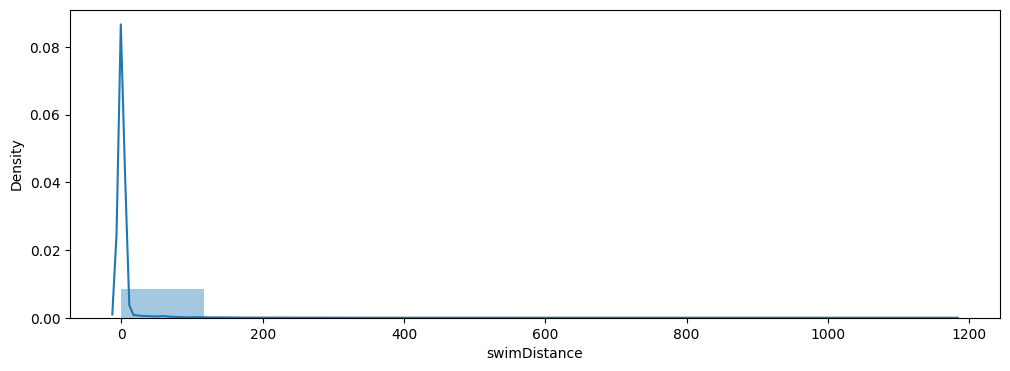

In [43]:
# Plot the distribution of swimDistance
plt.figure(figsize=(12,4))
sns.distplot(train['swimDistance'], bins=10)
plt.show()

In [44]:
# Players who swam more than 2 km
train[train['swimDistance'] >= 2]

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0.6400,2,0.00,181.1106,51.48,3518.46,0,1445.0445,False,0.00
13,b7807186e3f679,3c08e461874749,2c30ddf481c52d,0,1,324.20,0,1,5,5,...,0.8750,2,7.92,641.9160,192.06,3734.28,6,3354.8400,False,0.25
14,8e244ac61b6aab,d40d0c7d3573a1,94e1c1cc443c65,0,1,122.80,1,0,2,25,...,0.9000,1,1.99,244.3720,61.69,2901.42,3,2963.2900,False,0.00
17,92022479b92ce7,2f2c33f548c4b9,07948d723b9c0f,0,3,254.30,0,0,12,13,...,0.8211,1,3.98,506.0570,191.04,2728.29,15,4169.2900,False,0.00
19,71cbdbc3b263e5,7b61f74b51906c,a329ac99449ad7,0,1,65.28,0,0,1,48,...,0.9310,1,0.00,129.9072,59.70,2630.78,2,3330.8500,False,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20590,1450618b992d5c,42774dba45489a,1727ff0ca471ad,0,4,100.00,1,0,5,25,...,0.9259,1,1.99,199.0000,55.72,2696.45,9,3795.0100,False,0.00
20594,710cadfcf0e2a3,247bc30f2ce2c7,d8e0a8563e3d71,0,5,348.60,0,0,7,49,...,0.7333,1,0.00,693.7140,61.69,3611.85,12,10850.4100,False,0.00
20608,64531f9879d94a,e236a42f67f006,14ad094b129eb1,0,4,244.30,1,0,3,10,...,0.9556,1,3.98,486.1570,91.54,3755.13,7,7299.9800,False,0.00
20640,7459e33be7766e,a4d1e3677fa908,4c6e64c90dc681,0,1,0.00,0,0,2,52,...,0.6735,2,0.00,0.0000,99.00,4338.18,3,2593.1600,False,0.00


In [45]:
# Remove outliers
train.drop(train[train['swimDistance'] >= 2000].index, inplace=True)

**Anomalies in supplies (weaponsAcquired)**

Most people acquire between 0 and 10 weapons in a game, but you also see some people acquire more than 80 weapons! Let's check these guys out.

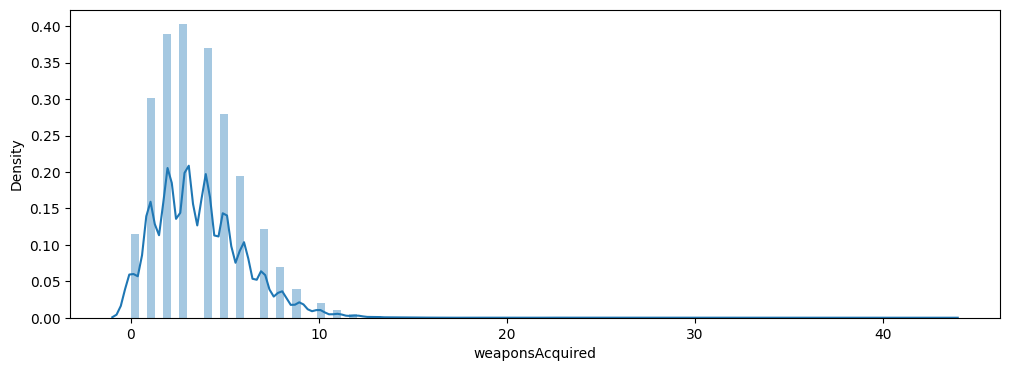

In [46]:
# Plot the distribution of weaponsAcquired
plt.figure(figsize=(12,4))
sns.distplot(train['weaponsAcquired'], bins=100)
plt.show()

In [47]:
# Players who acquired more than 80 weapons
display(train[train['weaponsAcquired'] >= 8].shape)
train[train['weaponsAcquired'] >= 8].head()

(1338, 38)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
10,2b574d43972813,c549efede67ad3,2dd6ddb8320fc1,0,0,28.38,0,0,0,75,...,0.3929,1,0.00,56.4762,57.71,3603.89,0,868.3,False,0.0
33,4b604176d374e0,0be145f90609b1,b2f1bb79ad4298,0,2,65.47,0,0,2,61,...,0.5200,1,0.00,130.2853,51.74,2682.52,4,751.8,False,0.0
100,18d002b46b1abc,00a3f236559532,eccc44618c0442,0,1,236.00,0,0,7,7,...,0.9355,1,5.97,469.6400,187.06,2831.77,8,1913.0,False,0.0
158,bf6960a8fe929e,abf0e2c2955d80,9808fc99c819bf,0,0,100.00,1,0,0,30,...,0.6538,1,1.99,199.0000,53.73,3777.02,0,1675.0,False,0.0
227,29ff255cadb0e6,a59084dc2da2e0,9fd63a42d97ed7,0,2,145.40,1,1,0,17,...,0.4130,1,3.98,289.3460,93.53,3534.24,2,2017.3,False,0.5


In [48]:
# Remove outliers
train.drop(train[train['weaponsAcquired'] >= 80].index, inplace=True)

We should probably remove these outliers from our model. Do you agree?

Note that player 3f2bcf53b108c4 acquired 236 weapons in one game!

![Alt Text](https://media.giphy.com/media/69lWR6c8Afx9qeg2Tu/giphy.gif)

**Anomalies in supplies part 2 (heals)**

Most players us 5 healing items or less. We can again recognize some weird anomalies

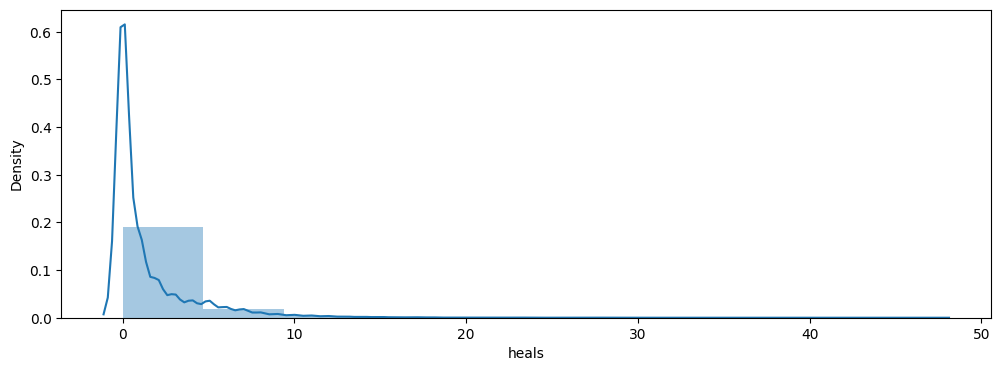

In [49]:
# Distribution of heals
plt.figure(figsize=(12,4))
sns.distplot(train['heals'], bins=10)
plt.show()

In [50]:
# 40 or more healing items used
display(train[train['heals'] >= 4].shape)
train[train['heals'] >= 4].head(10)

(2896, 38)

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,winPlacePerc,playersJoined,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,healsandboosts,totalDistance,killsWithoutMoving,headshot_rate
13,b7807186e3f679,3c08e461874749,2c30ddf481c52d,0,1,324.20,0,1,5,5,...,0.8750,2,7.92,641.9160,192.06,3734.28,6,3354.840,False,0.25
16,62f2f0917d84b2,f61b698274d9f5,1d6cfe0f6f23b0,0,2,81.71,1,0,14,25,...,0.7308,1,1.99,162.6029,53.73,3745.18,16,4193.900,False,0.00
17,92022479b92ce7,2f2c33f548c4b9,07948d723b9c0f,0,3,254.30,0,0,12,13,...,0.8211,1,3.98,506.0570,191.04,2728.29,15,4169.290,False,0.00
20,02ace8c6e58461,a4bc548028f800,80f2b8448e474b,0,4,269.10,0,1,8,18,...,0.6383,1,3.98,535.5090,95.52,3761.10,12,4528.000,False,0.50
25,4c45dc732689ec,8e0a0ea95d3596,37f43ba55ec0a4,1,4,558.60,3,0,4,11,...,0.8696,1,5.97,1111.6140,93.53,3663.59,8,3894.000,False,0.00
44,46ec2eef21c254,0fe2d5264ebb8e,a1a7ef866a79be,0,4,401.20,3,0,6,27,...,0.7872,2,1.98,794.3760,95.04,3771.90,10,2576.000,False,0.00
55,d79cdeb0ac6eb5,82ff744317632e,6c79fb59bd74c2,2,4,560.80,5,2,9,4,...,0.6400,1,9.95,1115.9920,51.74,2734.26,13,2190.000,False,0.40
60,5c46a37a783839,fcdc3ec45f9aea,2f985254dfe02b,0,1,170.00,1,1,4,16,...,0.7200,2,3.96,336.6000,51.48,2627.46,5,3182.000,False,0.50
61,dd87e30dc17eff,629ff5d2728458,f4f95b16c74a74,1,4,135.20,1,0,4,8,...,0.9091,1,5.97,269.0480,89.55,2565.11,8,2593.000,False,0.00
65,b83ba80e820303,c7979543803b35,56369e162a028b,0,1,192.50,0,0,8,27,...,0.5417,2,1.98,381.1500,49.50,3443.22,9,1382.268,False,0.00


In [51]:
# Remove outliers
train.drop(train[train['heals'] >= 40].index, inplace=True)

**Outlier conclusions**

We removed about 2000 players from our dataset. Do you think this is too much? Please let us know in the comments.

In [52]:
# Remaining players in the training set
train.shape

(20644, 38)

# Categorical Variables <a id="7"></a>

We will one hot encode the 'matchType' feature to use it in our Random Forest model.

In [53]:
print('There are {} different Match types in the dataset.'.format(train['matchType'].nunique()))

There are 15 different Match types in the dataset.


In [54]:
# One hot encode matchType
train = pd.get_dummies(train, columns=['matchType'])

# Take a look at the encoding
matchType_encoding = train.filter(regex='matchType')
matchType_encoding.head()

,matchType_crashfpp,matchType_crashtpp,matchType_duo,matchType_duo-fpp,matchType_flarefpp,matchType_flaretpp,matchType_normal-duo,matchType_normal-duo-fpp,matchType_normal-solo-fpp,matchType_normal-squad,matchType_normal-squad-fpp,matchType_solo,matchType_solo-fpp,matchType_squad,matchType_squad-fpp
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


There are a lot of groupId's and matchId's so one-hot encoding them is computational suicide.
We will turn them into category codes. That way we can still benefit from correlations between groups and matches in our Random Forest algorithm.

In [55]:
# Turn groupId and match Id into categorical types
train['groupId'] = train['groupId'].astype('category')
train['matchId'] = train['matchId'].astype('category')

# Get category coding for groupId and matchID
train['groupId_cat'] = train['groupId'].cat.codes
train['matchId_cat'] = train['matchId'].cat.codes

# Get rid of old columns
train.drop(columns=['groupId', 'matchId'], inplace=True)

# Lets take a look at our newly created features
train[['groupId_cat', 'matchId_cat']].head()

,groupId_cat,matchId_cat
0,6233,10616
1,8363,11527
2,8534,1124
3,13523,15851
4,17726,7216


In [56]:
# Drop Id column, because it probably won't be useful for our Machine Learning algorithm,
# because the test set contains different Id's
train.drop(columns = ['Id'], inplace=True)

**voilà!**

# Preparation for Machine Learning <a id="8"></a>

## Sampling

We will take a sample of 500000 rows from our training set for easy debugging and exploration.

In [57]:
# Take sample for debugging and exploration
sample = 20000
df_sample = train.sample(sample)

## Split target variable, validation data, etc.

In [58]:
# Split sample into training data and target variable
df = df_sample.drop(columns = ['winPlacePerc']) #all columns except target
y = df_sample['winPlacePerc'] # Only target variable

In [59]:
# Function for splitting training and validation data
def split_vals(a, n : int):
    return a[:n].copy(), a[n:].copy()
val_perc = 0.12 # % to use for validation set
n_valid = int(val_perc * sample)
n_trn = len(df)-n_valid
# Split data
raw_train, raw_valid = split_vals(df_sample, n_trn)
X_train, X_valid = split_vals(df, n_trn)
y_train, y_valid = split_vals(y, n_trn)

# Check dimensions of samples
print('Sample train shape: ', X_train.shape,
      'Sample target shape: ', y_train.shape,
      'Sample validation shape: ', X_valid.shape)

Sample train shape:  (17600, 50) Sample target shape:  (17600,) Sample validation shape:  (2400, 50)


## Set metrics (MAE)

[Mean Absolute Error (MAE)](https://en.wikipedia.org/wiki/Mean_absolute_error) is the metric that is used for this competition. The scikit-learn library already programmed this metric for us so we don't have to implement it from scratch.

In [60]:
# Metric used for the PUBG competition (Mean Absolute Error (MAE))
from sklearn.metrics import mean_absolute_error

# Function to print the MAE (Mean Absolute Error) score
# This is the metric used by Kaggle in this competition
def print_score(m : RandomForestRegressor):
    res = ['mae train: ', mean_absolute_error(m.predict(X_train), y_train),
           'mae val: ', mean_absolute_error(m.predict(X_valid), y_valid)]
    if hasattr(m, 'oob_score_'): res.append(m.oob_score_)
    print(res)

## First basic Random Forest Model

In [61]:
# Train basic model
m1 = RandomForestRegressor(n_estimators=40, min_samples_leaf=3, max_features='sqrt',
                          n_jobs=-1)
m1.fit(X_train, y_train)
print_score(m1)

['mae train: ', 0.04542063491142416, 'mae val: ', 0.07323064109593205]


# Feature Importance <a id="9"></a>

The [fastai](https://www.fast.ai/) library gives us an easy way to analyze feature importances from a random forest algorithm with just one line of code!

In [62]:
# What are the most predictive features according to our basic random forest model
fi = rf_feat_importance(m1, df); fi[:10]

,cols,imp
30,totalDistance,0.200748
21,walkDistance,0.186004
6,killPlace,0.170709
29,healsandboosts,0.087337
1,boosts,0.072692
22,weaponsAcquired,0.055319
26,damageDealtNorm,0.032397
16,rideDistance,0.021773
5,heals,0.020337
2,damageDealt,0.015380


<Axes: ylabel='cols'>

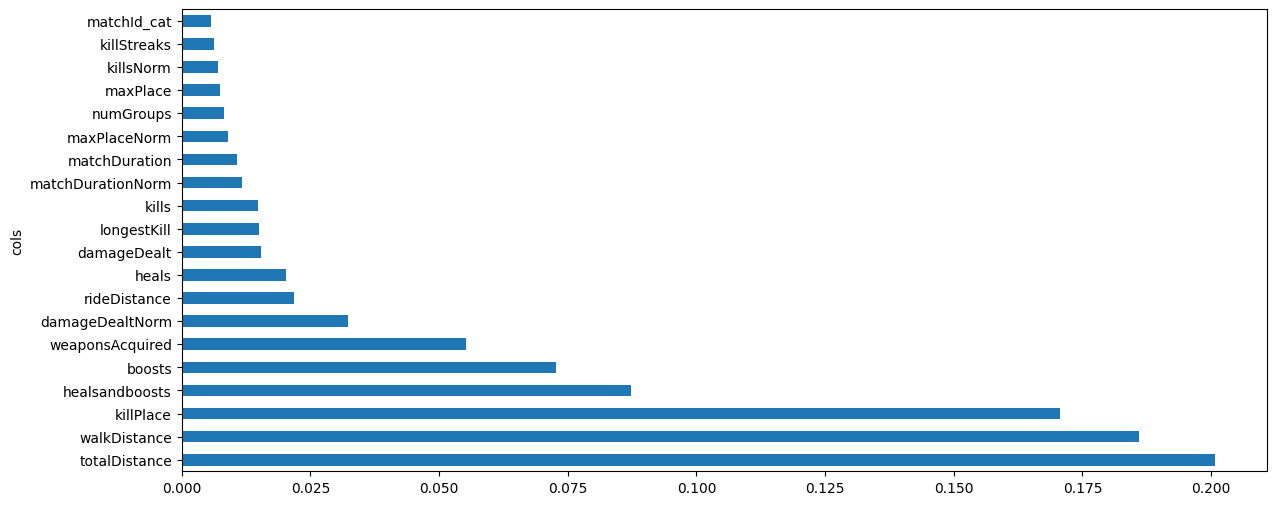

In [63]:
# Plot a feature importance graph for the 20 most important features
plot1 = fi[:20].plot('cols', 'imp', figsize=(14,6), legend=False, kind = 'barh')
plot1

In [64]:
# Use this code if you want to save the figure
#fig = plot1.get_figure()
#fig.savefig("Feature_importances(AllFeatures).png")

In [65]:
# Keep only significant features
to_keep = fi[fi.imp>0.005].cols
print('Significant features: ', len(to_keep))
to_keep

Significant features:  22


,cols
30,totalDistance
21,walkDistance
6,killPlace
29,healsandboosts
1,boosts
22,weaponsAcquired
26,damageDealtNorm
16,rideDistance
5,heals
2,damageDealt


In [66]:
# Make a DataFrame with only significant features
df_keep = df[to_keep].copy()
X_train, X_valid = split_vals(df_keep, n_trn)

## Second Random Forest Model

This time we use only the top features to train a random forest model. This often improves results a little bit.

In [67]:
# Train model on top features
m2 = RandomForestRegressor(n_estimators=80, min_samples_leaf=3, max_features='sqrt',
                          n_jobs=-1)
m2.fit(X_train, y_train)
print_score(m2)

['mae train: ', 0.04307927856073135, 'mae val: ', 0.07213817320954384]


**Feature importance for top features**

<Axes: ylabel='cols'>

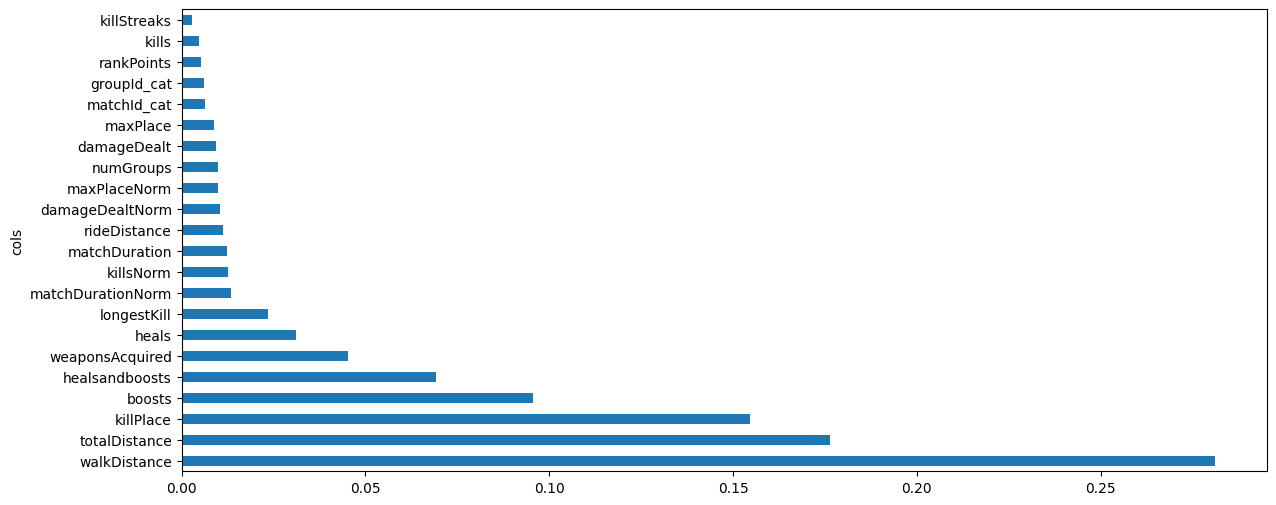

In [68]:
# Get feature importances of our top features
fi_to_keep = rf_feat_importance(m2, df_keep)
plot2 = fi_to_keep.plot('cols', 'imp', figsize=(14,6), legend=False, kind = 'barh')
plot2

# Use this code if you want to save the figure
#fig = plot2.get_figure()
#fig.savefig("Feature_importances(TopFeatures).png")

## Correlations

**Dendrogram (to view correlation of features)**

[]

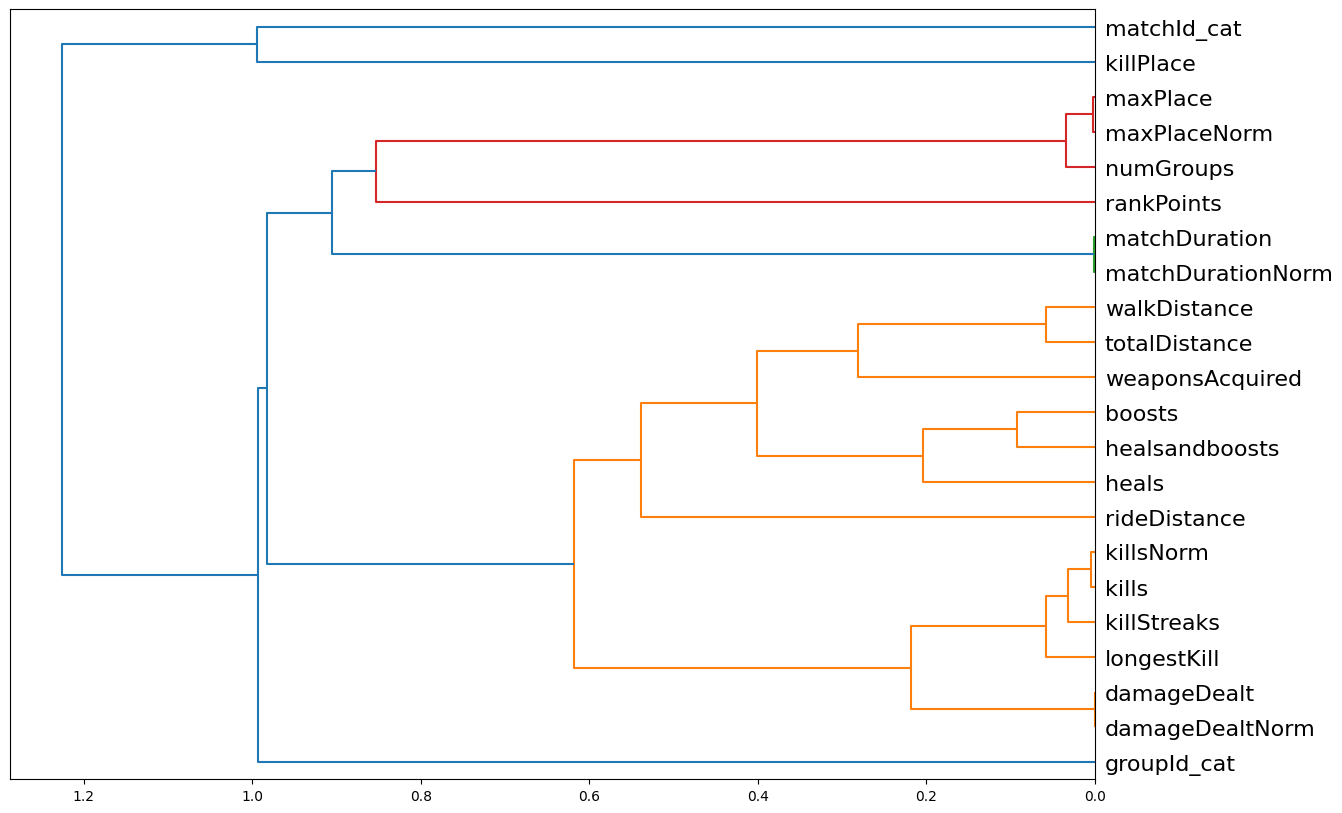

In [69]:
# Create a Dendrogram to view highly correlated features
corr = np.round(scipy.stats.spearmanr(df_keep).correlation, 4)
corr_condensed = hc.distance.squareform(1-corr)
z = hc.linkage(corr_condensed, method='average')
fig = plt.figure(figsize=(14,10))
dendrogram = hc.dendrogram(z, labels=df_keep.columns, orientation='left', leaf_font_size=16)
plt.plot()

In [70]:
# Use this code if you want to save the figure
#plt.savefig('Dendrogram.png')

**Correlation Heatmap**

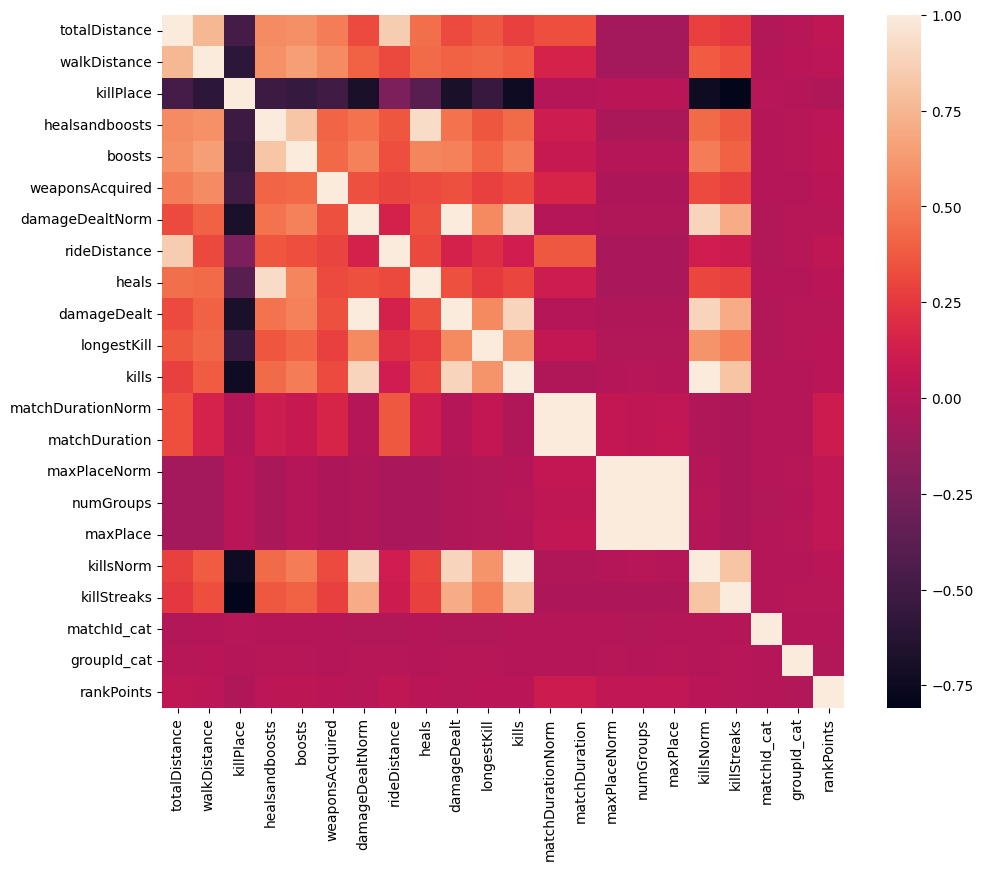

In [71]:
# Correlation heatmap
corr = df_keep.corr()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Create heatmap
heatmap = sns.heatmap(corr)

In [72]:
# Use this code if you want to save the figure
#fig = heatmap.get_figure()
#fig.savefig("Heatmap(TopFeatures).png")

**Predictive quality of kills**

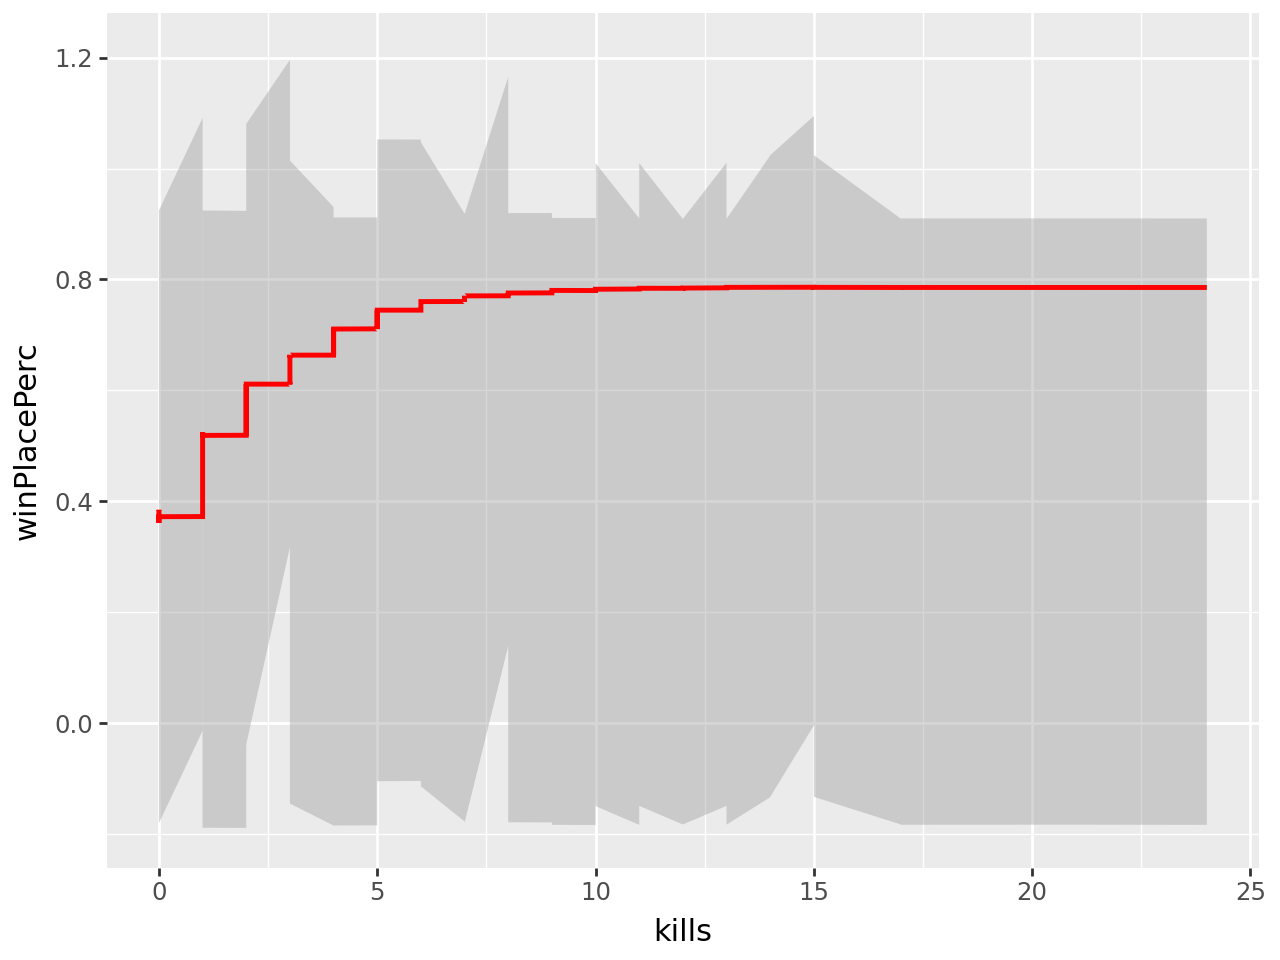

In [73]:
# Plot the predictive quality of kills
x_all = get_sample(train, 100000)
ggplot(x_all, aes('kills','winPlacePerc'))+stat_smooth(se=True, colour='red', method='mavg')

**Predictive quality of walkDistance**

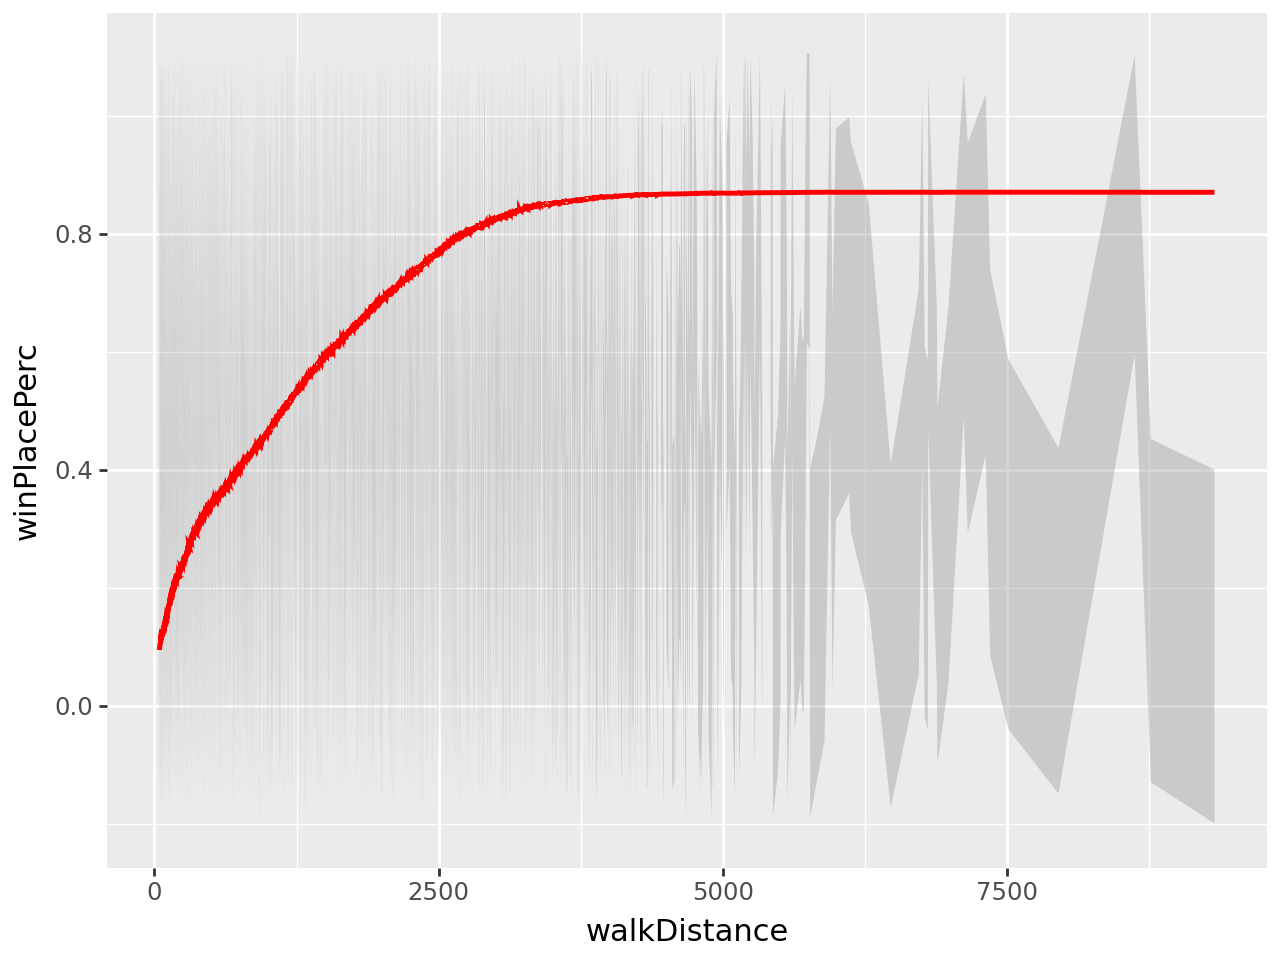

In [74]:
# Plot the predictive quality of walkDistance
x_all = get_sample(train, 100000)
ggplot(x_all, aes('walkDistance','winPlacePerc'))+stat_smooth(se=True, colour='red', method='mavg')

# Final Random Forest Model <a id="10"></a>

In [75]:
# Prepare data
val_perc_full = 0.12 # % to use for validation set
n_valid_full = int(val_perc_full * len(train))
n_trn_full = len(train)-n_valid_full
df_full = train.drop(columns = ['winPlacePerc']) # all columns except target
y = train['winPlacePerc'] # target variable
df_full = df_full[to_keep] # Keep only relevant features
X_train, X_valid = split_vals(df_full, n_trn_full)
y_train, y_valid = split_vals(y, n_trn_full)

# Check dimensions of data
print('Sample train shape: ', X_train.shape,
      'Sample target shape: ', y_train.shape,
      'Sample validation shape: ', X_valid.shape)

Sample train shape:  (18167, 22) Sample target shape:  (18167,) Sample validation shape:  (2477, 22)


In [76]:
# Train final model
# You should get better results by increasing n_estimators
# and by playing around with the parameters
m3 = RandomForestRegressor(n_estimators=70, min_samples_leaf=3, max_features=0.5,
                          n_jobs=-1)
m3.fit(X_train, y_train)
print_score(m3)

['mae train: ', 0.036276676748222804, 'mae val: ', 0.06806194233349135]


# Kaggle Submission <a id="11"></a>

In [77]:
# Add engineered features to the test set
test['headshot_rate'] = test['headshotKills'] / test['kills']
test['headshot_rate'] = test['headshot_rate'].fillna(0)
test['totalDistance'] = test['rideDistance'] + test['walkDistance'] + test['swimDistance']
test['playersJoined'] = test.groupby('matchId')['matchId'].transform('count')
test['killsNorm'] = test['kills']*((100-test['playersJoined'])/100 + 1)
test['damageDealtNorm'] = test['damageDealt']*((100-test['playersJoined'])/100 + 1)
test['maxPlaceNorm'] = test['maxPlace']*((100-train['playersJoined'])/100 + 1)
test['matchDurationNorm'] = test['matchDuration']*((100-test['playersJoined'])/100 + 1)
test['healsandboosts'] = test['heals'] + test['boosts']
test['killsWithoutMoving'] = ((test['kills'] > 0) & (test['totalDistance'] == 0))

# Turn groupId and match Id into categorical types
test['groupId'] = test['groupId'].astype('category')
test['matchId'] = test['matchId'].astype('category')

# Get category coding for groupId and matchID
test['groupId_cat'] = test['groupId'].cat.codes
test['matchId_cat'] = test['matchId'].cat.codes

# Remove irrelevant features from the test set
test_pred = test[to_keep].copy()

# Fill NaN with 0 (temporary)
test_pred.fillna(0, inplace=True)
test_pred.head()

,totalDistance,walkDistance,killPlace,healsandboosts,boosts,weaponsAcquired,damageDealtNorm,rideDistance,heals,damageDealt,...,matchDurationNorm,matchDuration,maxPlaceNorm,numGroups,maxPlace,killsNorm,killStreaks,matchId_cat,groupId_cat,rankPoints
0,588.0,588.0,73,0,0,1,102.4054,0.0,0,51.46,...,3749.16,1884,55.44,28,28,0.00,0,2479,4234,1500
1,6686.0,2017.0,11,6,4,6,356.4090,4669.0,2,179.10,...,3603.89,1811,95.04,47,48,3.98,1,2356,2772,1503
2,787.8,787.8,49,4,0,4,46.5660,0.0,4,23.40,...,3568.07,1793,55.72,27,28,0.00,0,4830,479,1565
3,1812.0,1812.0,54,0,0,3,129.7296,0.0,0,65.52,...,3631.32,1834,88.20,44,45,0.00,0,988,7440,1465
4,2963.0,2963.0,7,5,4,4,650.4940,0.0,1,330.20,...,2612.22,1326,55.72,27,28,5.91,1,2283,4166,1480


In [78]:
# Make submission ready for Kaggle
# We use our final Random Forest model (m3) to get the predictions
predictions = np.clip(a = m3.predict(test_pred), a_min = 0.0, a_max = 1.0)
pred_df = pd.DataFrame({'Id' : test['Id'], 'winPlacePerc' : predictions})

# Create submission file
pred_df.to_csv("submission.csv", index=False)

**Check of submission file**

It is always nice to take a look at few of your predictions to make sure that the structure is right for a Kaggle submission.

In [79]:
# Last check of submission
print('Head of submission: ')
display(pred_df.head())
print('Tail of submission: ')
display(pred_df.tail())

Head of submission: 


,Id,winPlacePerc
0,9329eb41e215eb,0.269776
1,639bd0dcd7bda8,0.860391
2,63d5c8ef8dfe91,0.511916
3,cf5b81422591d1,0.581276
4,ee6a295187ba21,0.912728


Tail of submission: 


,Id,winPlacePerc
10325,fef949fe99841b,0.373829
10326,da93b428dcee39,0.863883
10327,1557c02acdd916,0.656915
10328,f004e300197d71,0.527443
10329,753ad2ad5ffb59,0.234134


In [80]:
# sklearn/XGBoost/LightGBM/CatBOOST, PyTorch MPL

In [81]:
# !pip -q install -U xgboost lightgbm catboost shap ydata-profiling

In [82]:
import os
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

In [83]:
# 2. read all data
CANDIDATES = [("train_V2.csv","test_V2.csv"),
        ("train_V2_sample.csv", "test_V2_sample.csv"),
        ("train.csv", "test.csv"),      ]

train_path = None
test_path = None
for tr, te in CANDIDATES:
    if os.path.exists(tr) and os.path.exists(te):
        train_path, test_path = tr, te
        break

if train_path is None:
  train_path = "/train_V2_sample.csv"
  test_path = "/test_V2_sample.csv"

print("Using:", train_path, test_path)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

Using: train_V2_sample.csv test_V2_sample.csv


In [84]:
display (train.describe (include = 'all').T.head(20))
print("missing target:", train['winPlacePerc'].isna().sum())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,20650,20650,0030f752f98f50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
groupId,20650,20548,a8be41a95bdc0e,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
matchId,20650,16832,666a33eef8b58c,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assists,20650.0,NaN,NaN,NaN,0.238111,0.586472,0.0,0.0,0.0,0.0,9.0
boosts,20650.0,NaN,NaN,NaN,1.132397,1.738985,0.0,0.0,0.0,2.0,14.0
damageDealt,20650.0,NaN,NaN,NaN,131.183393,170.752296,0.0,0.0,82.515,186.375,2856.0
DBNOs,20650.0,NaN,NaN,NaN,0.665085,1.168246,0.0,0.0,0.0,1.0,32.0
headshotKills,20650.0,NaN,NaN,NaN,0.225182,0.576507,0.0,0.0,0.0,0.0,8.0
heals,20650.0,NaN,NaN,NaN,1.389395,2.70119,0.0,0.0,0.0,2.0,47.0
killPlace,20650.0,NaN,NaN,NaN,47.414383,27.495482,1.0,24.0,47.0,71.0,100.0


missing target: 0


In [85]:
def add_group_match_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()


    if 'rankPoints' in df.columns:
        df['rankPoints'] = df['rankPoints'].replace(-1, 0)

    # base numeric features
    drop_cols = {'Id', 'groupId', 'matchId', 'winPlacePerc'}
    base_num = [c for c in df.columns if c not in drop_cols and df[c].dtype != 'object']

    # group size / match size
    df['group_size'] = df.groupby(['matchId', 'groupId'])['Id'].transform('count')
    df['match_size'] = df.groupby('matchId')['Id'].transform('count')

    # group mean
    group_mean = df.groupby(['matchId', 'groupId'])[base_num].transform('mean')
    group_mean.columns = [f"{c}_gmean" for c in base_num]
    df = pd.concat([df, group_mean], axis=1)

    # group max
    group_max = df.groupby(['matchId', 'groupId'])[base_num].transform('max')
    group_max.columns = [f"{c}_gmax" for c in base_num]
    df = pd.concat([df, group_max], axis=1)

    # normalization first step
    df['kills_per_walk'] = df['kills'] / (df['walkDistance'] + 1.0)
    df['damage_per_walk'] = df['damageDealt'] / (df['walkDistance'] + 1.0)
    df['heals_boosts'] = df['heals'] + df['boosts']

    return df

train_fe = add_group_match_features(train)
test_fe  = add_group_match_features(test)

# Normalization
train_fe = train_fe.dropna(subset=['winPlacePerc']).reset_index(drop=True)

print("After FE - train:", train_fe.shape, "test:", test_fe.shape)
train_fe.head()

After FE - train: (20650, 82) test: (10330, 81)


,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,roadKills_gmax,swimDistance_gmax,teamKills_gmax,vehicleDestroys_gmax,walkDistance_gmax,weaponsAcquired_gmax,winPoints_gmax,kills_per_walk,damage_per_walk,heals_boosts
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.00,0,0,244.80,1,1466,0.000000,0.000000,0
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,11.04,0,0,1434.00,5,0,0.000000,0.063742,0
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.00,0,0,161.80,2,0,0.000000,0.417690,0
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.00,0,0,202.70,3,0,0.000000,0.161512,0
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.00,0,0,49.75,2,0,0.019704,1.970443,0


5.切分：按照matchld group split

In [86]:
TARGET = 'winPlacePerc'

X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET].astype(float)

groups = train_fe['matchId']
gss = GroupShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
train_idx, valid_idx = next(gss.split(X, y, groups = groups))

X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[valid_idx].copy()

print(X_train.shape, X_valid.shape)

(16501, 81) (4149, 81)


6.预处理 + 多模型训练（ML：machine learning机器学习）

In [87]:
# 分列
drop_cols = ["Id", "matchId", "groupId"]
X_train = X_train.drop(columns=drop_cols)
X_valid = X_valid.drop(columns=drop_cols)

cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # sparse=True
])

numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),  # 稀疏矩阵兼容
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ],
    remainder="drop",
)

def eval_model(name, model):
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    mae = mean_absolute_error(y_valid, pred)
    return mae, pipe

models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
}

results = []
fitted = {}

for name, model in models.items():
    mae, pipe = eval_model(name, model)
    results.append((name, mae))
    fitted[name] = pipe
    print(f"{name:12s}  valid MAE = {mae:.5f}")

results = sorted(results, key=lambda x: x[1])
results

Ridge         valid MAE = 0.09109


[('Ridge', 0.09108903476862139)]

7. Boosting: XGBoost/LightGBM/CatBoost

In [88]:
boost_results = []
boost_models = {}

# 注意：这些库对稀疏 one-hot 特征很友好
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
    mae, pipe = eval_model("XGBoost", xgb)
    boost_results.append(("XGBoost", mae))
    boost_models["XGBoost"] = pipe
    print(f"XGBoost      valid MAE = {mae:.5f}")
except Exception as e:
    print("[Skip] XGBoost:", repr(e))

try:
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(
        n_estimators=6000,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )
    mae, pipe = eval_model("LightGBM", lgbm)
    boost_results.append(("LightGBM", mae))
    boost_models["LightGBM"] = pipe
    print(f"LightGBM     valid MAE = {mae:.5f}")
except Exception as e:
    print("[Skip] LightGBM:", repr(e))

try:
    from catboost import CatBoostRegressor
    # CatBoost 原生能处理类别，但这里我们已经 one-hot；简单起见按数值输入走
    cat = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.03,
        depth=8,
        loss_function="MAE",
        random_seed=42,
        verbose=200,
    )
    mae, pipe = eval_model("CatBoost", cat)
    boost_results.append(("CatBoost", mae))
    boost_models["CatBoost"] = pipe
    print(f"CatBoost     valid MAE = {mae:.5f}")
except Exception as e:
    print("[Skip] CatBoost:", repr(e))

sorted(boost_results, key=lambda x: x[1])


XGBoost      valid MAE = 0.06262
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8672
[LightGBM] [Info] Number of data points in the train set: 16501, number of used features: 85
[LightGBM] [Info] Start training from score 0.475600
LightGBM     valid MAE = 0.06373
[Skip] CatBoost: ModuleNotFoundError("No module named 'catboost'")


[('XGBoost', 0.06261689239775768), ('LightGBM', 0.06373165461830238)]

## 8. 深度学习：PyTorch Tabular MLP（示例）

思路：
- 复用同一套 `preprocess` 得到系数特征矩阵
- 转成 float32 张量，训练一个小型的 MLP 回归器
- 早停（early stopping）+ 验证 MAE

> 对 tabular 数据，树模型通常更强；但这里加入 DL 作为“扩展模块”。

In [89]:
# 安装/导入 torch（Colab 一般自带：没有则安装）
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except Exception:
    !pip -q install torch
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [90]:
# 先 fit preprocess，再 transform 成稀疏矩阵
prep_fitted = preprocess.fit(X_train)

Xtr_sp = prep_fitted.transform(X_train)
Xva_sp = prep_fitted.transform(X_valid)

# 稀疏 -> dense（样本不大时 OK；如果你用全量数据，建议用更高效的 sparse 训练方案）
# Xtr = torch.tensor(Xtr_sp.toarray(), dtype=torch.float32)
# Xva = torch.tensor(Xva_sp.toarray(), dtype=torch.float32)
Xtr = torch.tensor(Xtr_sp, dtype=torch.float32)
Xva = torch.tensor(Xva_sp, dtype=torch.float32)
ytr = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
yva = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(Xtr, ytr)
valid_ds = TensorDataset(Xva, yva)

train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=4096, shuffle=False)

Xtr.shape, Xva.shape

(torch.Size([16501, 92]), torch.Size([4149, 92]))

In [91]:
class MLPRegressor(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

def train_mlp(max_epochs=30, lr=1e-3, patience=5):
    model = MLPRegressor(Xtr.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.L1Loss()  # 直接优化 MAE

    best_mae = float("inf")
    best_state = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        # valid
        model.eval()
        with torch.no_grad():
            preds = []
            ys = []
            for xb, yb in valid_loader:
                xb = xb.to(device)
                pred = model(xb).cpu().numpy().reshape(-1)
                preds.append(pred)
                ys.append(yb.numpy().reshape(-1))
            preds = np.concatenate(preds)
            ys = np.concatenate(ys)
            mae = mean_absolute_error(ys, preds)

        print(f"Epoch {epoch:02d} | valid MAE: {mae:.5f}")

        if mae + 1e-6 < best_mae:
            best_mae = mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    return model, best_mae

mlp_model, mlp_mae = train_mlp()
mlp_mae

Epoch 01 | valid MAE: 0.14392
Epoch 02 | valid MAE: 0.10214
Epoch 03 | valid MAE: 0.09382
Epoch 04 | valid MAE: 0.09109
Epoch 05 | valid MAE: 0.08871
Epoch 06 | valid MAE: 0.08075
Epoch 07 | valid MAE: 0.08353
Epoch 08 | valid MAE: 0.07869
Epoch 09 | valid MAE: 0.07617
Epoch 10 | valid MAE: 0.08191
Epoch 11 | valid MAE: 0.07744
Epoch 12 | valid MAE: 0.07306
Epoch 13 | valid MAE: 0.07652
Epoch 14 | valid MAE: 0.07228
Epoch 15 | valid MAE: 0.07176
Epoch 16 | valid MAE: 0.07244
Epoch 17 | valid MAE: 0.07341
Epoch 18 | valid MAE: 0.08256
Epoch 19 | valid MAE: 0.07171
Epoch 20 | valid MAE: 0.06778
Epoch 21 | valid MAE: 0.08350
Epoch 22 | valid MAE: 0.07336
Epoch 23 | valid MAE: 0.06908
Epoch 24 | valid MAE: 0.07121
Epoch 25 | valid MAE: 0.06846
Early stopping.


0.06778187304735184

## 9. 选择最佳模型并训练全量，然后预测 test

- 选择验证集 MAE 最小的模型（树模型/boosting/MLP）
- 在全量 train 上拟合
- 输出 `submission.csv`（包含 `Id` 与 `winPlacePerc`）



In [92]:
# 汇总候选
all_candidates = []
all_candidates += results
all_candidates += boost_results
all_candidates += [("PyTorch_MLP", mlp_mae)]

best_name, best_mae = sorted(all_candidates, key=lambda x: x[1])[0]
best_name, best_mae

('XGBoost', 0.06261689239775768)

In [93]:
# 准备全量训练数据
X_full = train_fe.drop(columns=[TARGET])
y_full = train_fe[TARGET].astype(float)
X_test = test_fe.copy()

# 训练并预测
if best_name == "PyTorch_MLP":
    # 用同一 preprocess 在 full 上 fit
    prep_full = preprocess.fit(X_full)
    Xfull_sp = prep_full.transform(X_full)
    Xtest_sp = prep_full.transform(X_test)

    Xfull = torch.tensor(Xfull_sp.toarray(), dtype=torch.float32).to(device)
    yfull = torch.tensor(y_full.values, dtype=torch.float32).view(-1, 1).to(device)

    # 重新训练一个 MLP（这里不给验证集，训练 epoch 少一点）
    model = MLPRegressor(Xfull.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn = nn.L1Loss()

    model.train()
    for epoch in range(1, 11):
        # 简单全量训练
        idx = torch.randperm(Xfull.shape[0], device=device)
        for start in range(0, Xfull.shape[0], 2048):
            batch = idx[start:start+2048]
            xb = Xfull[batch]
            yb = yfull[batch]
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        print("epoch", epoch, "loss", float(loss))

    model.eval()
    with torch.no_grad():
        Xtest = torch.tensor(Xtest_sp.toarray(), dtype=torch.float32).to(device)
        test_pred = model(Xtest).detach().cpu().numpy().reshape(-1)

else:
    # 传统 ML：找到对应 pipe
    if best_name in fitted:
        best_pipe = fitted[best_name]
    else:
        best_pipe = boost_models[best_name]

    # 用全量重新 fit
    best_pipe.fit(X_full, y_full)
    test_pred = best_pipe.predict(X_test)

# clipping（目标范围 0~1）
test_pred = np.clip(test_pred, 0, 1)

submission = pd.DataFrame({
    "Id": test["Id"],
    "winPlacePerc": test_pred
})

submission.head()



,Id,winPlacePerc
0,9329eb41e215eb,0.247530
1,639bd0dcd7bda8,0.954638
2,63d5c8ef8dfe91,0.651918
3,cf5b81422591d1,0.552502
4,ee6a295187ba21,0.924112


In [94]:
# 保存
out_path = "submission.csv"
submission.to_csv(out_path, index=False)
print("Saved:", out_path, "rows:", len(submission))

Saved: submission.csv rows: 10330


## 10. 模型解释：SHAP（树模型更适合）

如果最佳模型是树/bossting,可以用 SHAP 看特征重要性（注意：特征很多时会慢）。

In [95]:
try:
    import shap
    shap.initjs()

    # 仅对非 MLP 且支持的模型做演示
    if best_name != "PyTorch_MPL":
        # 取一小部分样本避免太慢
        X_small = X_valid.sample(n=min(500, len(X_valid)), random_state=42)
        X_small_tr = best_pipe.named_step["prep"].transform(X_small)

        model = best_pipe.named_steps["model"]

        # shap 对不同模型的 explainer 不同；这里用通用 Explainer 尝试
        explainer = shap.Explainer(model, X_small_tr)
        shap_values = explainer(X_small_tr)

        shap.plots.beeswarm(shap_values, max_display=20)
    else:
        print("Best is MLP; SHAP demo skipped.")
except Exception as e:
    print("SHAP skipped:", repr(e))

SHAP skipped: AttributeError("'Pipeline' object has no attribute 'named_step'")
